# Cross-Dataset Model Analysis (H-CAST Baseline Style)

This notebook mirrors the structure of `hcast_analysis.ipynb`, but compares **models** across **datasets**.

It includes:
- per-dataset validation curves (`FPA`, `wAP`, `TICE`, `AHD`),
- per-dataset training loss curves,
- per-level training/validation curves,
- final test comparison tables.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from model_comparison_utils import (
    ModelComparisonAnalysis,
    ModelComparisonConfig,
    build_model_dataset_run_specs,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
# -------- Configuration --------
OUTPUT_ROOT = OUTPUTS_ROOT

MODEL_COLORS = {
    'hcast': '#1f77b4',
    'hrn': '#ff7f0e',
    'ht_capsnet': '#2ca02c',
    'lhdnn': '#d62728',
    'hiercos': '#cad627',
}

# Manual mode: choose run-name tokens here; runs are searched as {model}_{dataset}.
AUTO_DISCOVER = False
DATASET_NAMES = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft']  # cifar-100, cub-200-2011, fgvc-aircraft, inat21-mini
MODEL_NAMES = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']       # hcast, lhdnn, hrn, ht_capsnet, hiercos

MODEL_RUN_NAMES = {
    'ht_capsnet': 'capsnet',
}
DATASET_RUN_NAMES = {
    'inat21-mini': 'inat21-mini',
}
MODEL_LABELS = {
    'hcast': 'H-CAST',
    'hrn': 'HRN',
    'ht_capsnet': 'HT-CapsNet',
    'lhdnn': 'LH-DNN',
    'hiercos': 'HierCoS',
}
DATASET_LABELS = {}
RUN_NAME_OVERRIDES = {}
RUN_LABEL_OVERRIDES = {}
RUN_COLOR_OVERRIDES = {}
EXTRA_RUNS = []

MANUAL_RUNS = build_model_dataset_run_specs(
    MODEL_NAMES,
    DATASET_NAMES,
    model_run_names=MODEL_RUN_NAMES,
    dataset_run_names=DATASET_RUN_NAMES,
    model_labels=MODEL_LABELS,
    dataset_labels=DATASET_LABELS,
    run_name_overrides=RUN_NAME_OVERRIDES,
    run_label_overrides=RUN_LABEL_OVERRIDES,
    run_color_overrides=RUN_COLOR_OVERRIDES,
) + EXTRA_RUNS
MANUAL_RUN_DIRS = []  # Path-only shorthand kept for quick ad hoc additions.

# Optional filters (leave empty = keep everything)
INCLUDE_MODELS = []   # hcast, hrn, ht_capsnet, lhdnn, hiercos
INCLUDE_DATASETS = []  # DATASET_NAMES already selects datasets in manual mode.
INCLUDE_RUN_NAME_SUBSTRINGS = []
EXCLUDE_RUN_NAME_SUBSTRINGS = []

# Use this only when auto-discovering base runs named as model_dataset.
REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT = False

PREFERRED_DATASET_ORDER = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft']
PREFERRED_MODEL_ORDER = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']


In [3]:
config = ModelComparisonConfig(
    output_root=OUTPUT_ROOT,
    auto_discover=AUTO_DISCOVER,
    manual_runs=MANUAL_RUNS,
    manual_run_dirs=MANUAL_RUN_DIRS,
    include_models=INCLUDE_MODELS,
    include_datasets=INCLUDE_DATASETS,
    include_run_name_substrings=INCLUDE_RUN_NAME_SUBSTRINGS,
    exclude_run_name_substrings=EXCLUDE_RUN_NAME_SUBSTRINGS,
    require_model_dataset_run_name_format=REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT,
    preferred_dataset_order=PREFERRED_DATASET_ORDER,
    preferred_model_order=PREFERRED_MODEL_ORDER,
    model_colors=MODEL_COLORS,
)

analysis = ModelComparisonAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/lhdnn_aircraft
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_aircraft
Candidate run directories: 13
Parsed runs: 13
Filtered runs: 13

Selected runs
-------------
CIFAR-100
  - H-CAST       | run=hcast_cifar100                      | best_td=93/0.7522    | best_ind=93/0.7331    | test_FPA_td=74.28% | test_FPA_ind=72.39%
  - LH-DNN       | run=lhdnn_cifar100                      | best_td=14/0.4673    | best_ind=14/0.4448    | test_FPA_td=45.98% | test_FPA_ind=43.83%
  - HRN          | run=hrn_cifar100                        | best_td=2/0.2983     | best_ind=2/0.2376     | test_FPA_td=n/a | test_FPA_ind=n/a
  - HT-CapsNet   | run=capsnet_cifar100                    | best_td=76/0.7113    | best_ind=79/0.7036    | test_FPA_td=n/a | test_FPA_ind=n/a
  - HierCoS      | run=hiercos_cifar100                    | best_td=16/0.7671    | best_ind=16/0.7646    | test_FPA_td=76.20% | test_FPA_ind=75.95%
CU

## Validation Metrics Curves (Per Dataset)

Interpretation note:
- For `FPA` and `wAP`, higher is better.
- For `TICE` and `AHD`, lower is better.
- Solid lines are top-down metrics; dashed lines are independent metrics.


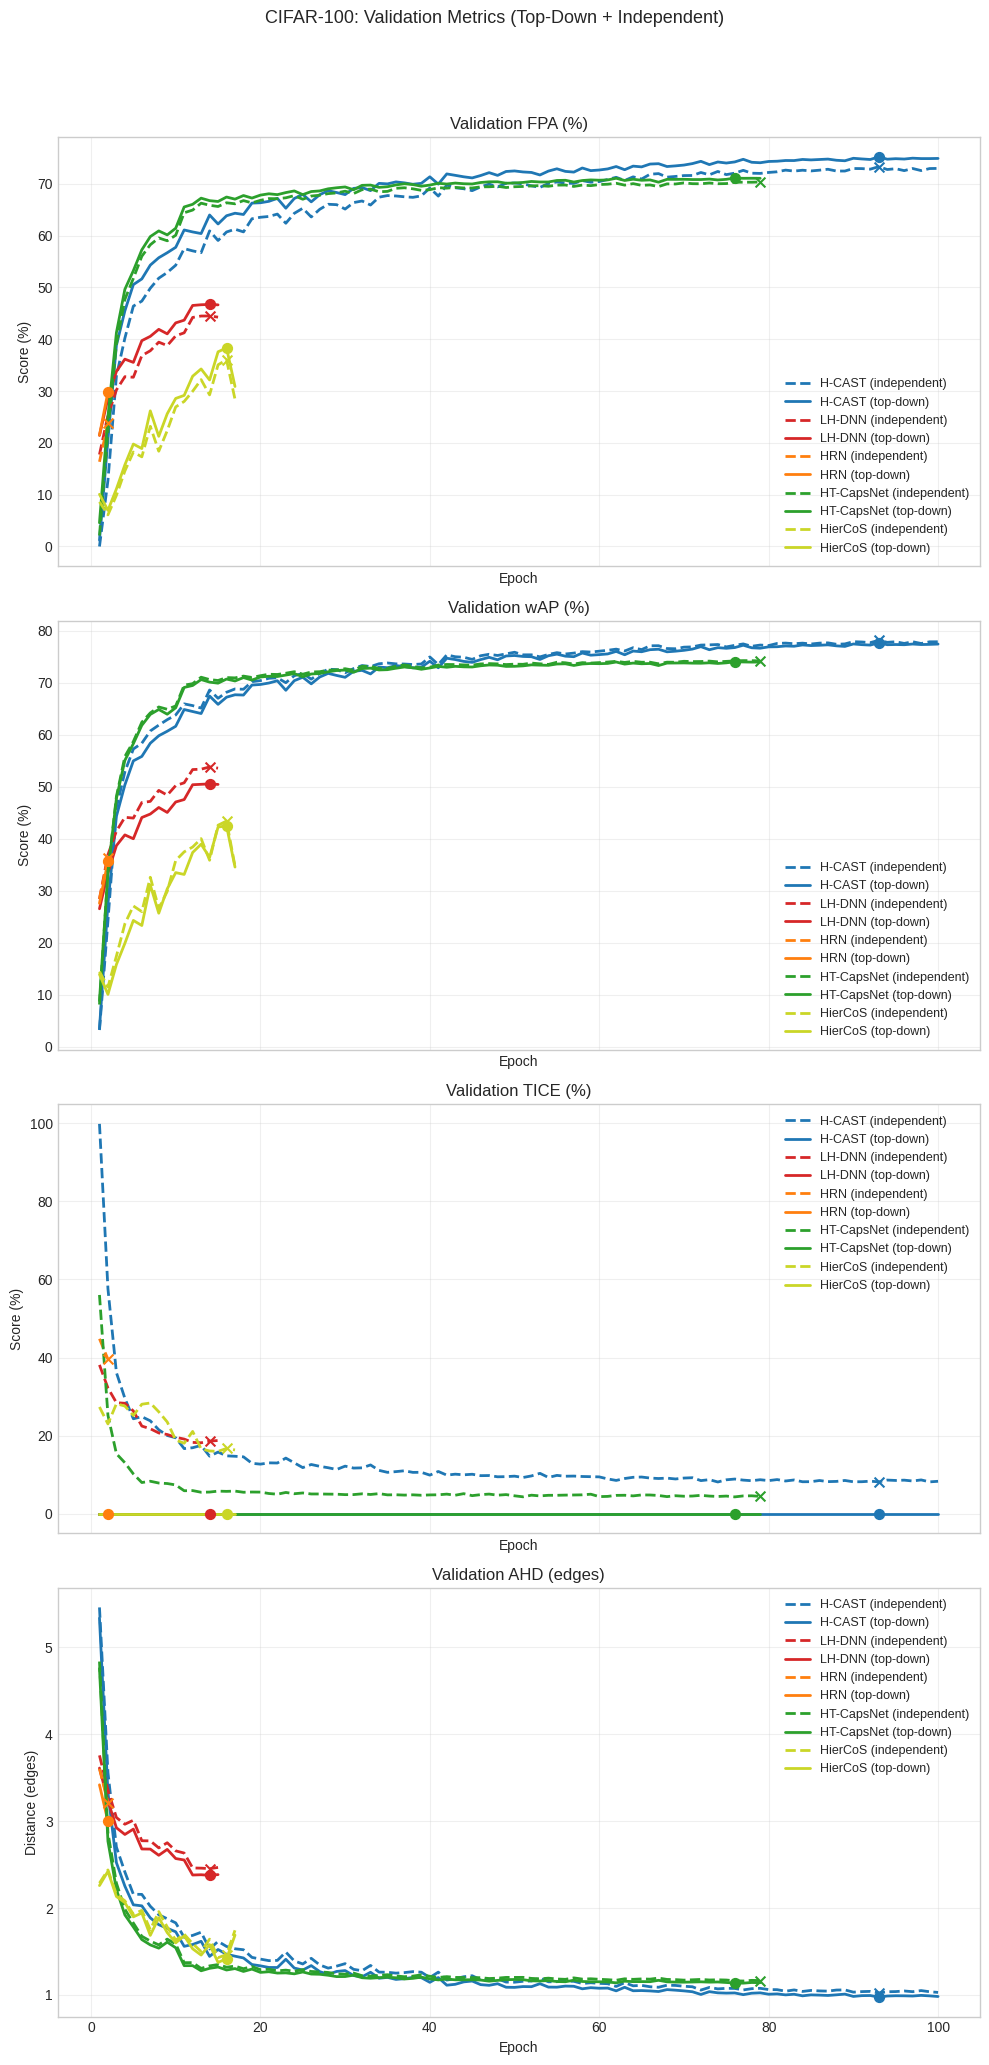

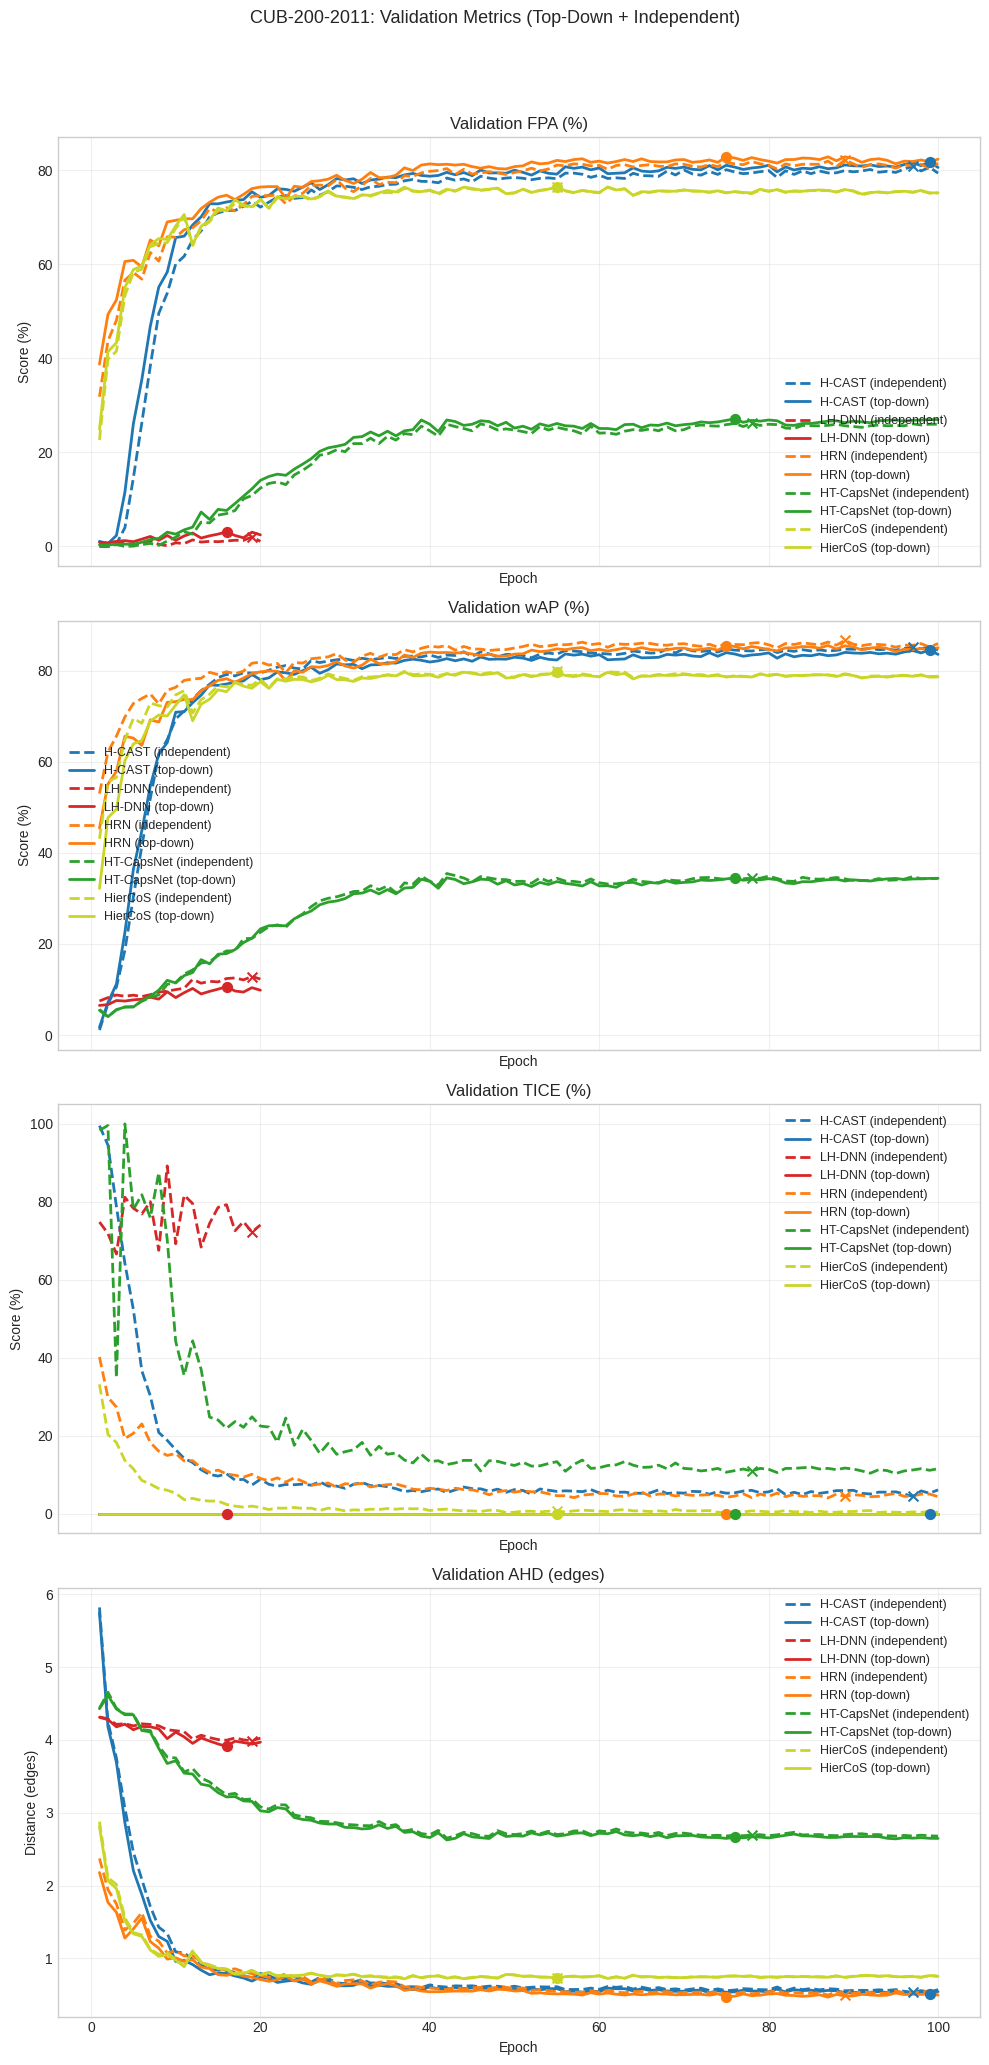

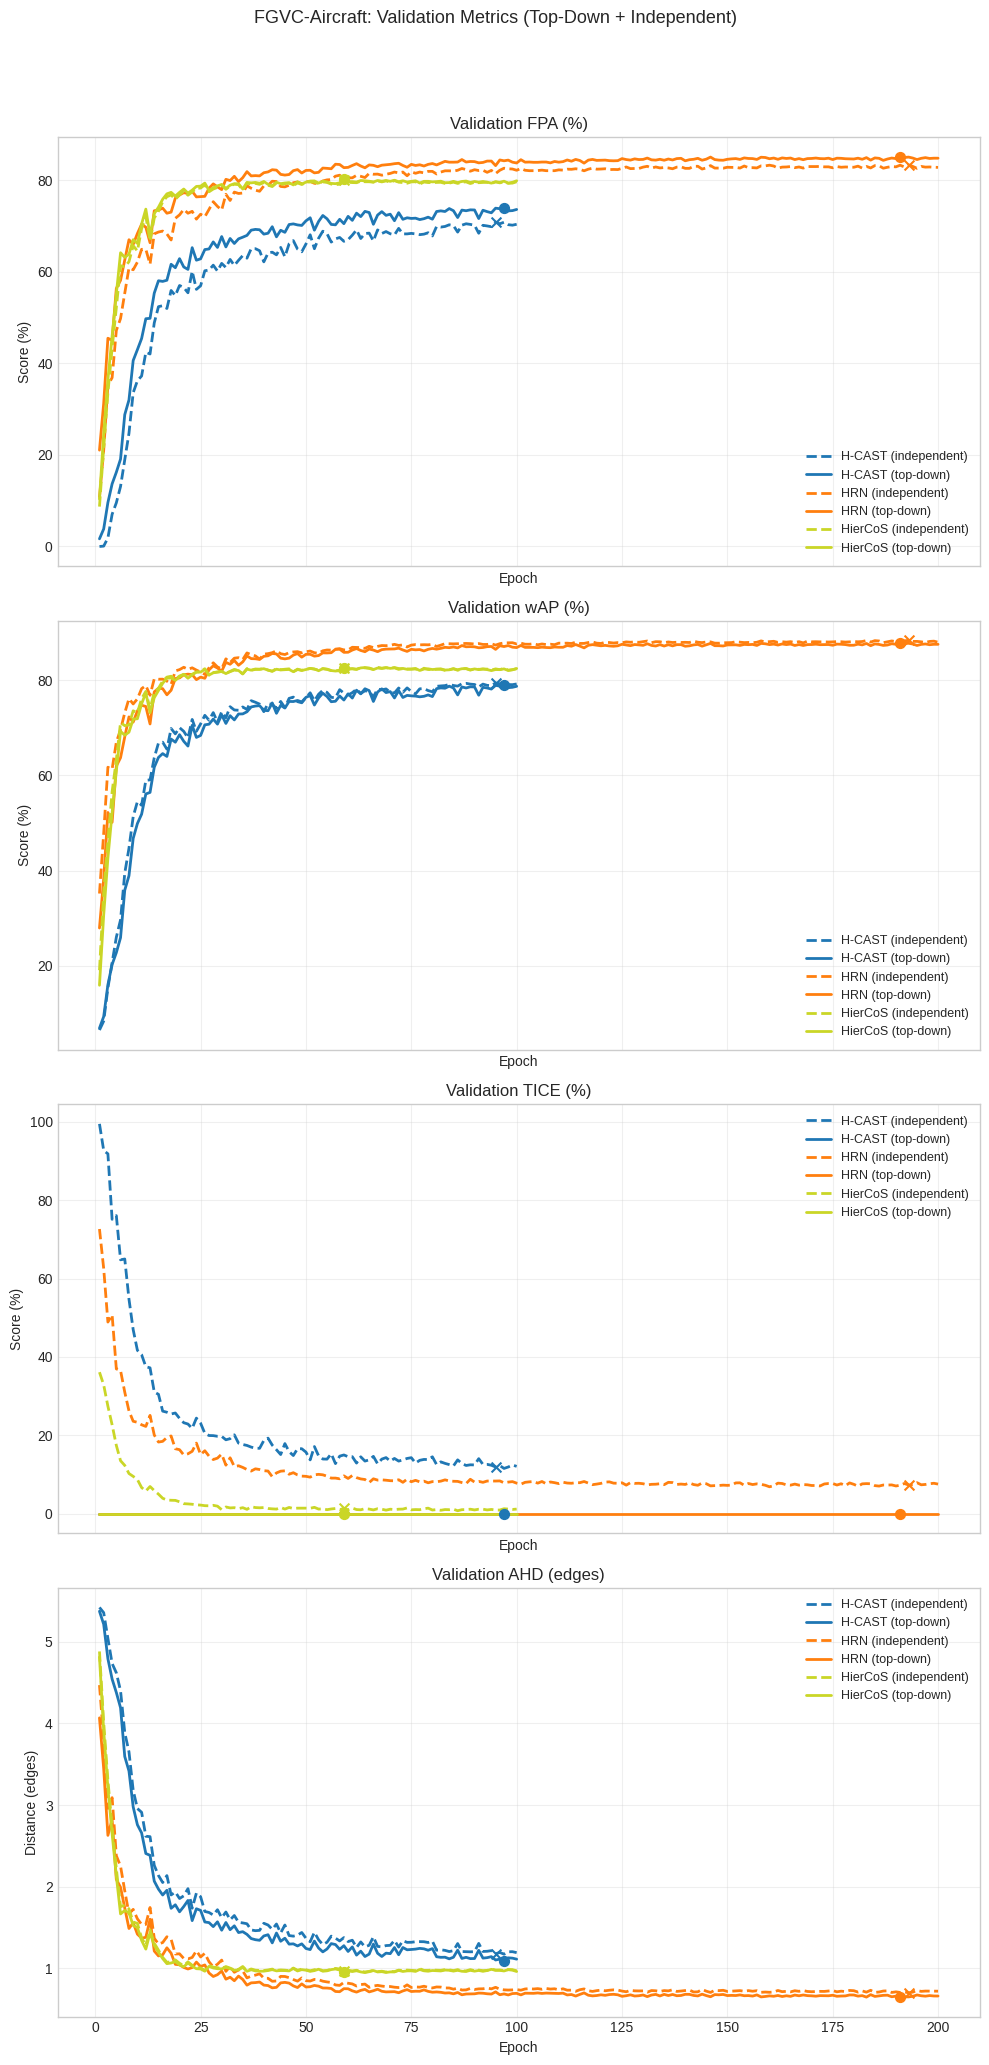

In [4]:
analysis.plot_validation_curves()


## Training Loss Comparison (Per Dataset)

Interpretation note:
- Lower is better for all loss curves.


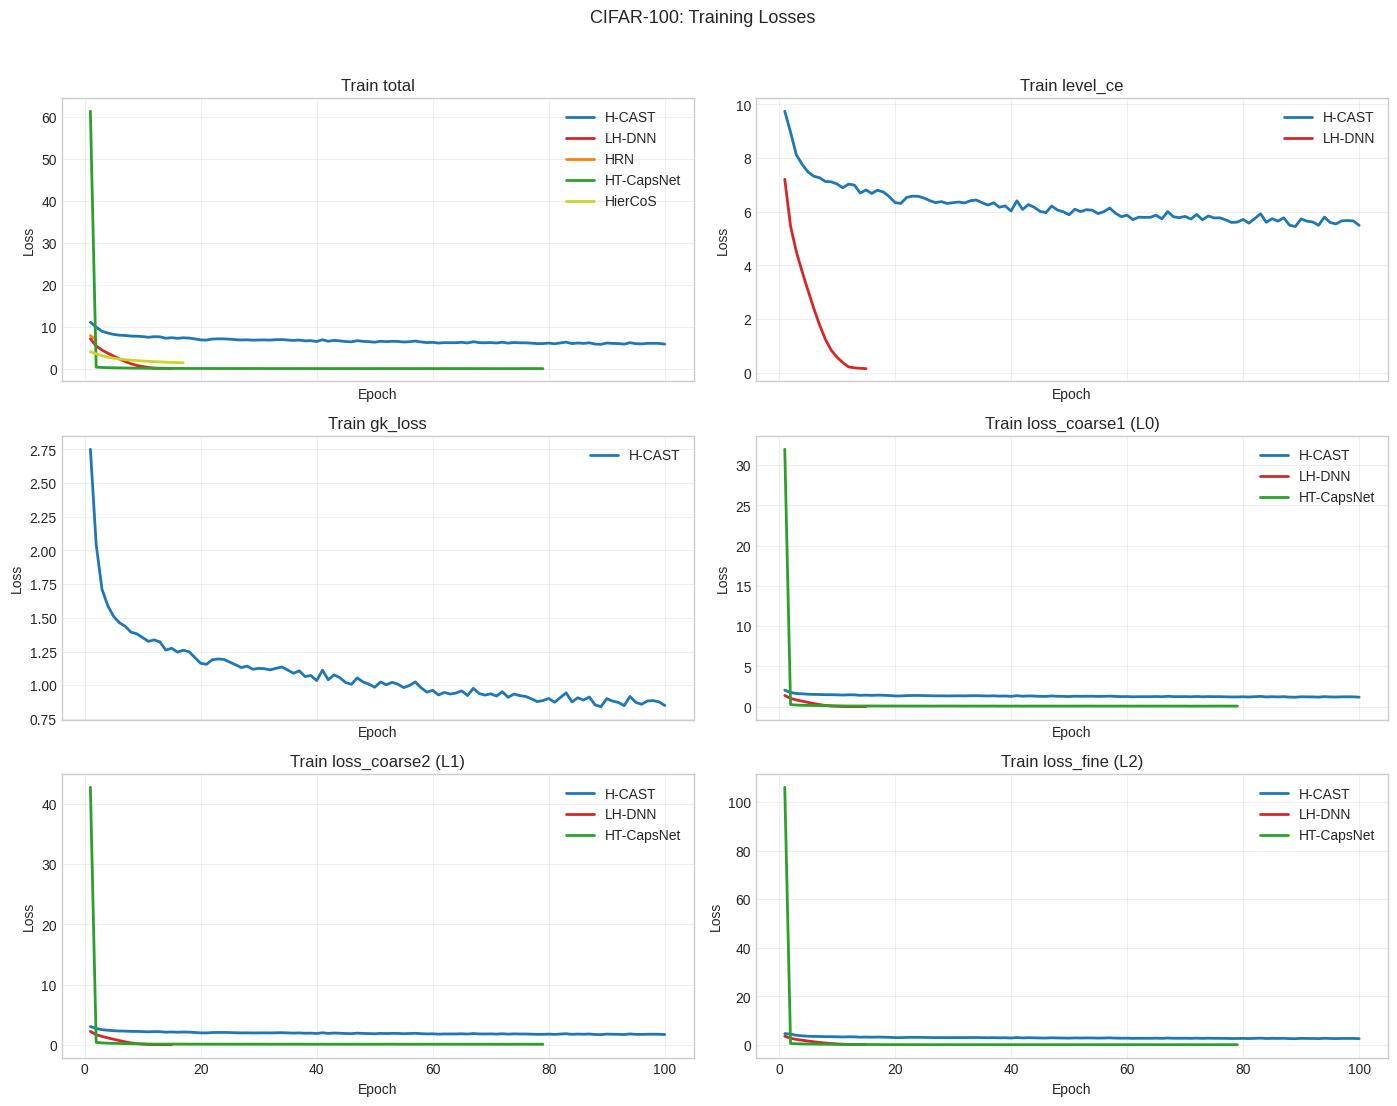

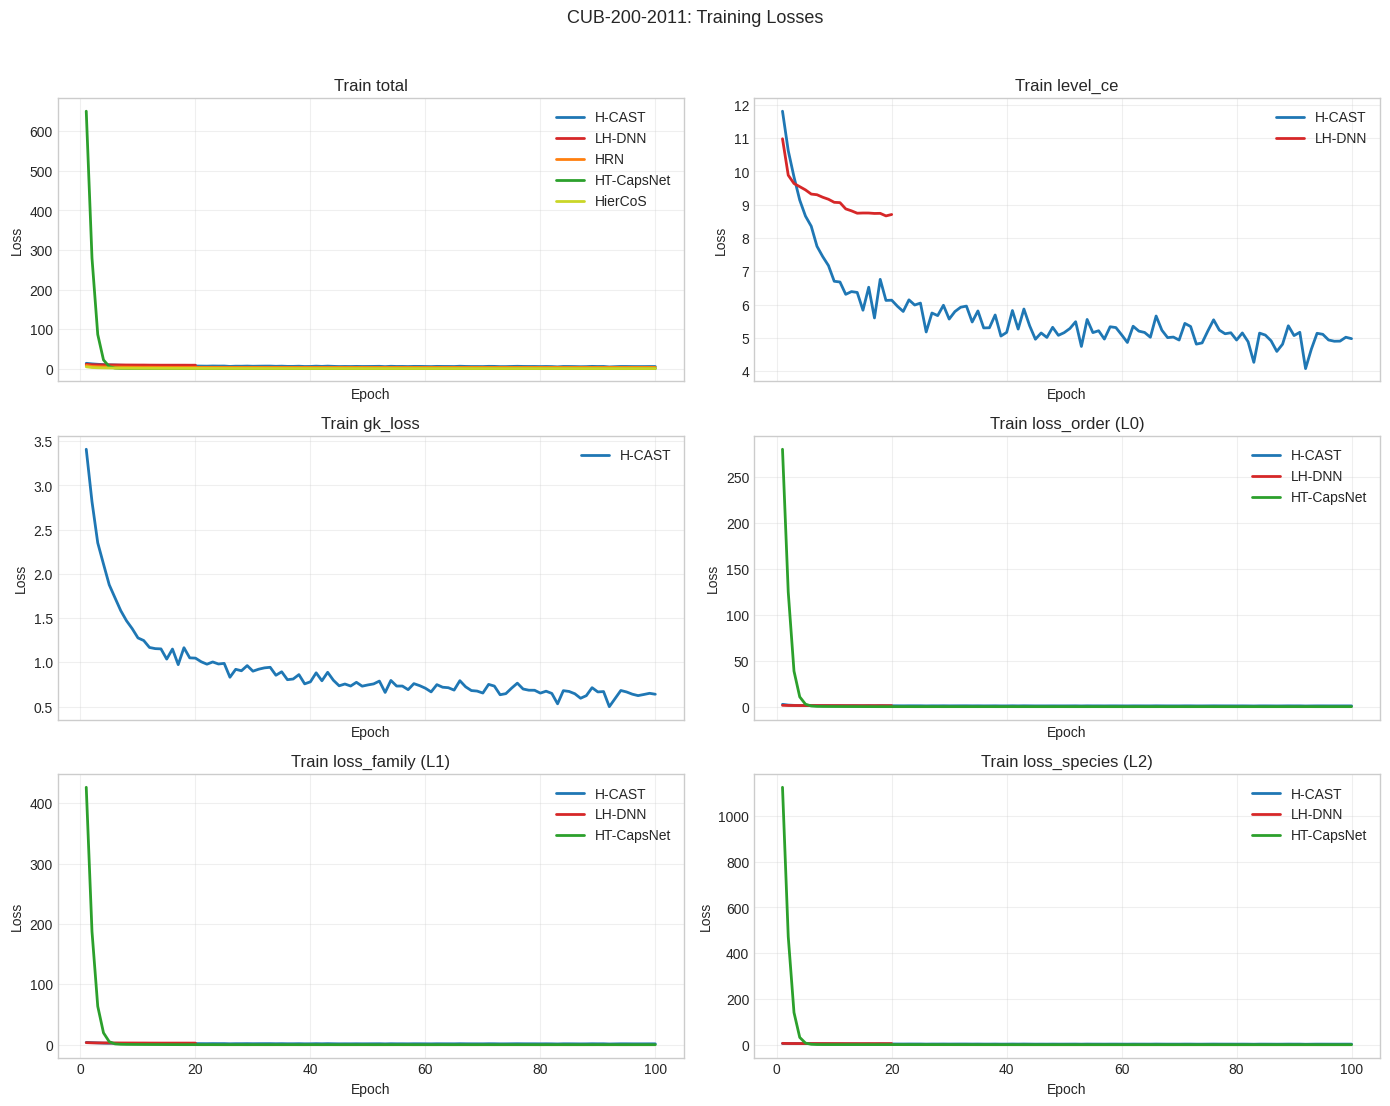

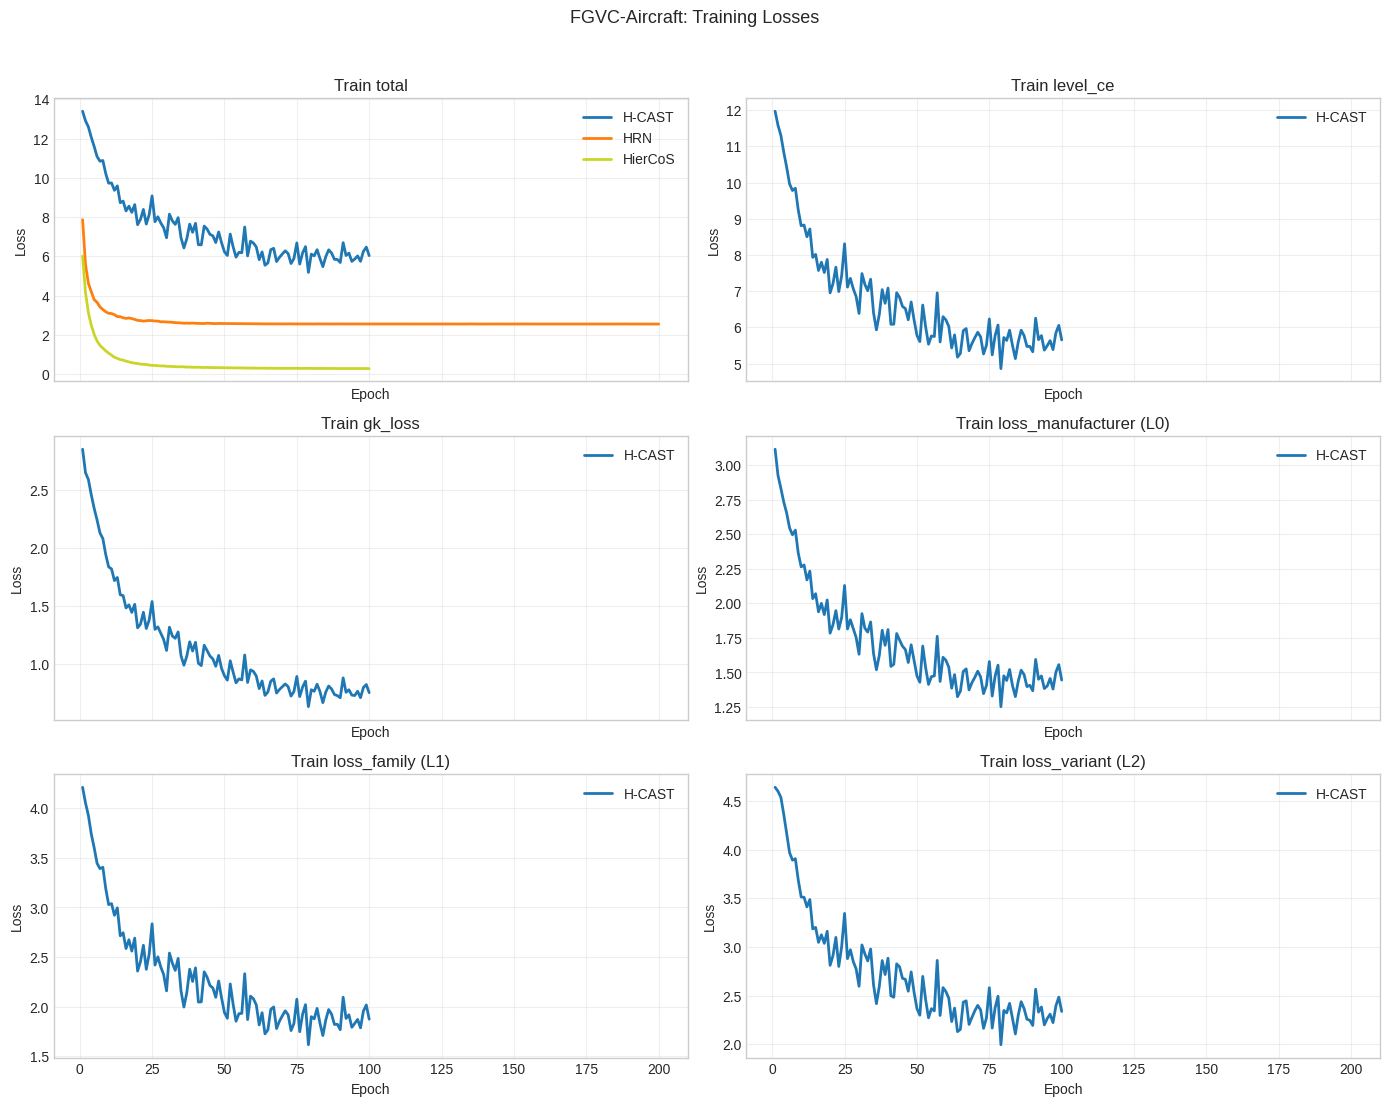

In [5]:
analysis.plot_training_losses_per_dataset()


## Per-Level Training Losses (Per Model and Dataset)

Interpretation note:
- Each chart corresponds to one selected `(model, dataset)` run.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).


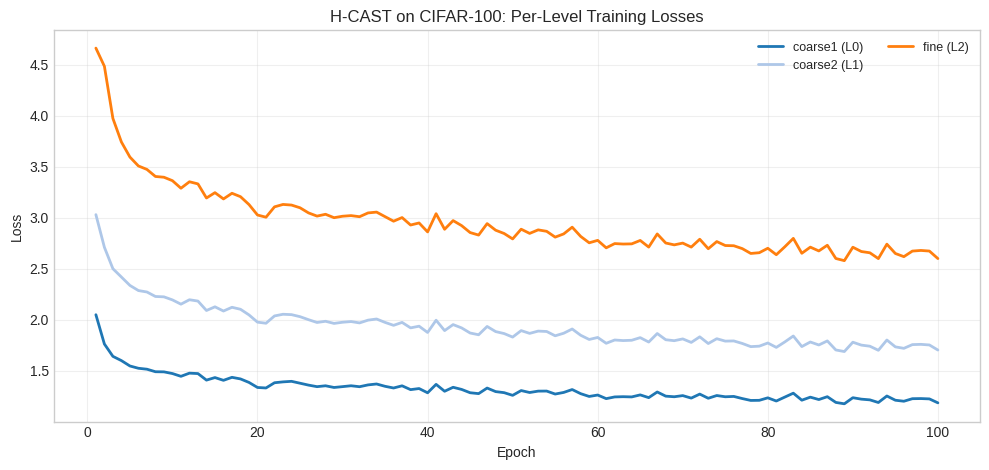

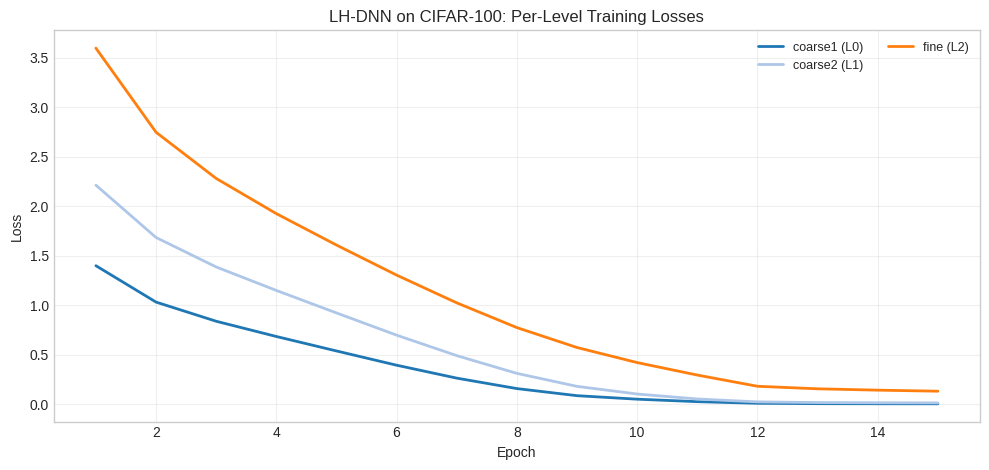

No per-level train losses for HRN on CIFAR-100


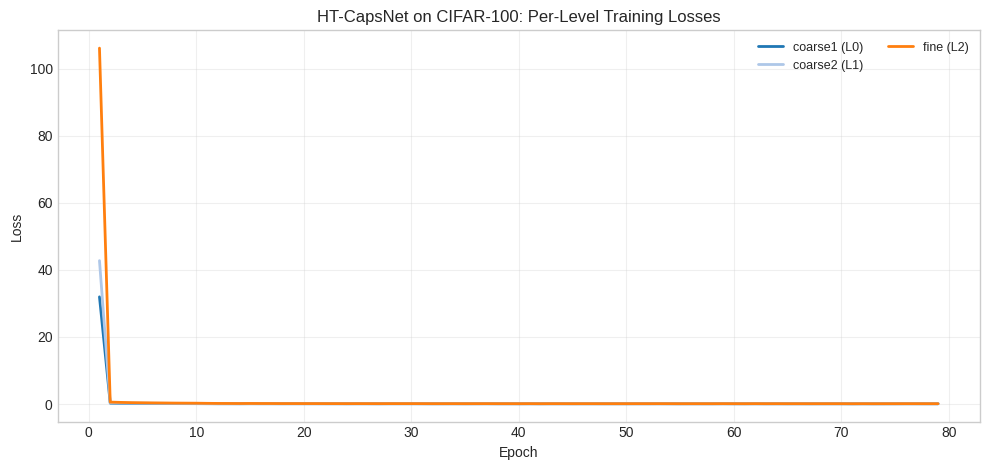

No per-level train losses for HierCoS on CIFAR-100


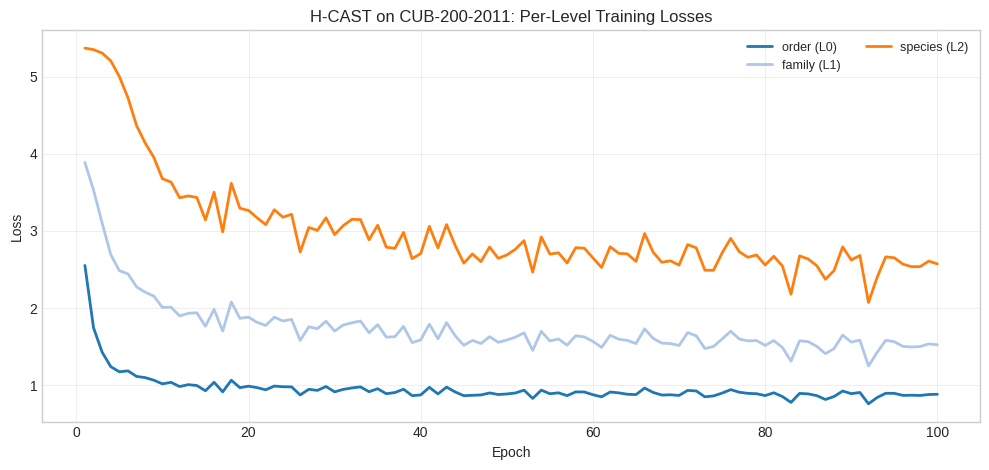

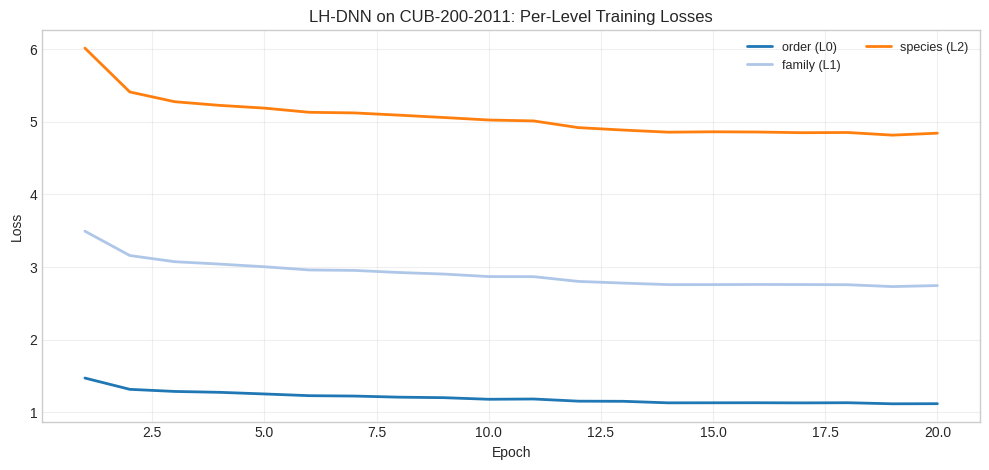

No per-level train losses for HRN on CUB-200-2011


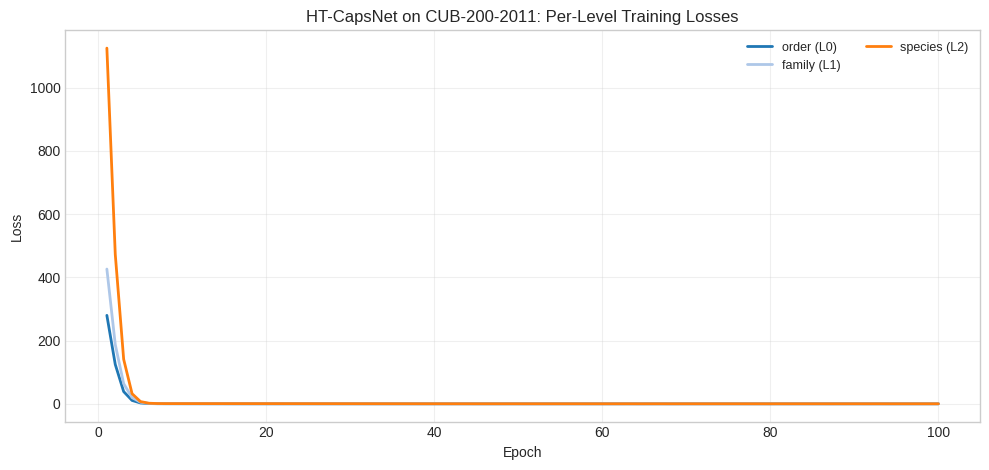

No per-level train losses for HierCoS on CUB-200-2011


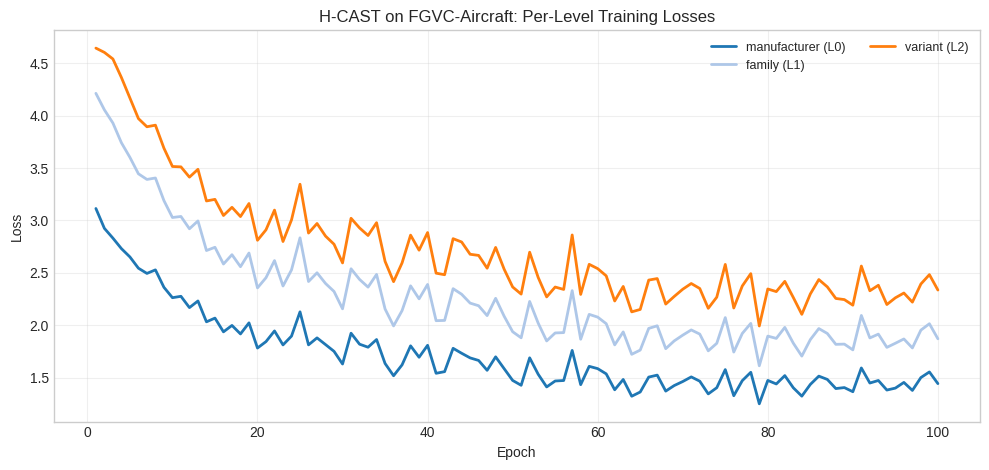

No per-level train losses for HRN on FGVC-Aircraft
No per-level train losses for HierCoS on FGVC-Aircraft


In [6]:
analysis.plot_per_run_per_level_training_losses()


## Per-Level Validation Accuracy (Top-Down and Independent)

Interpretation note:
- Solid vs dashed of the same color shows top-down vs independent for the same model.


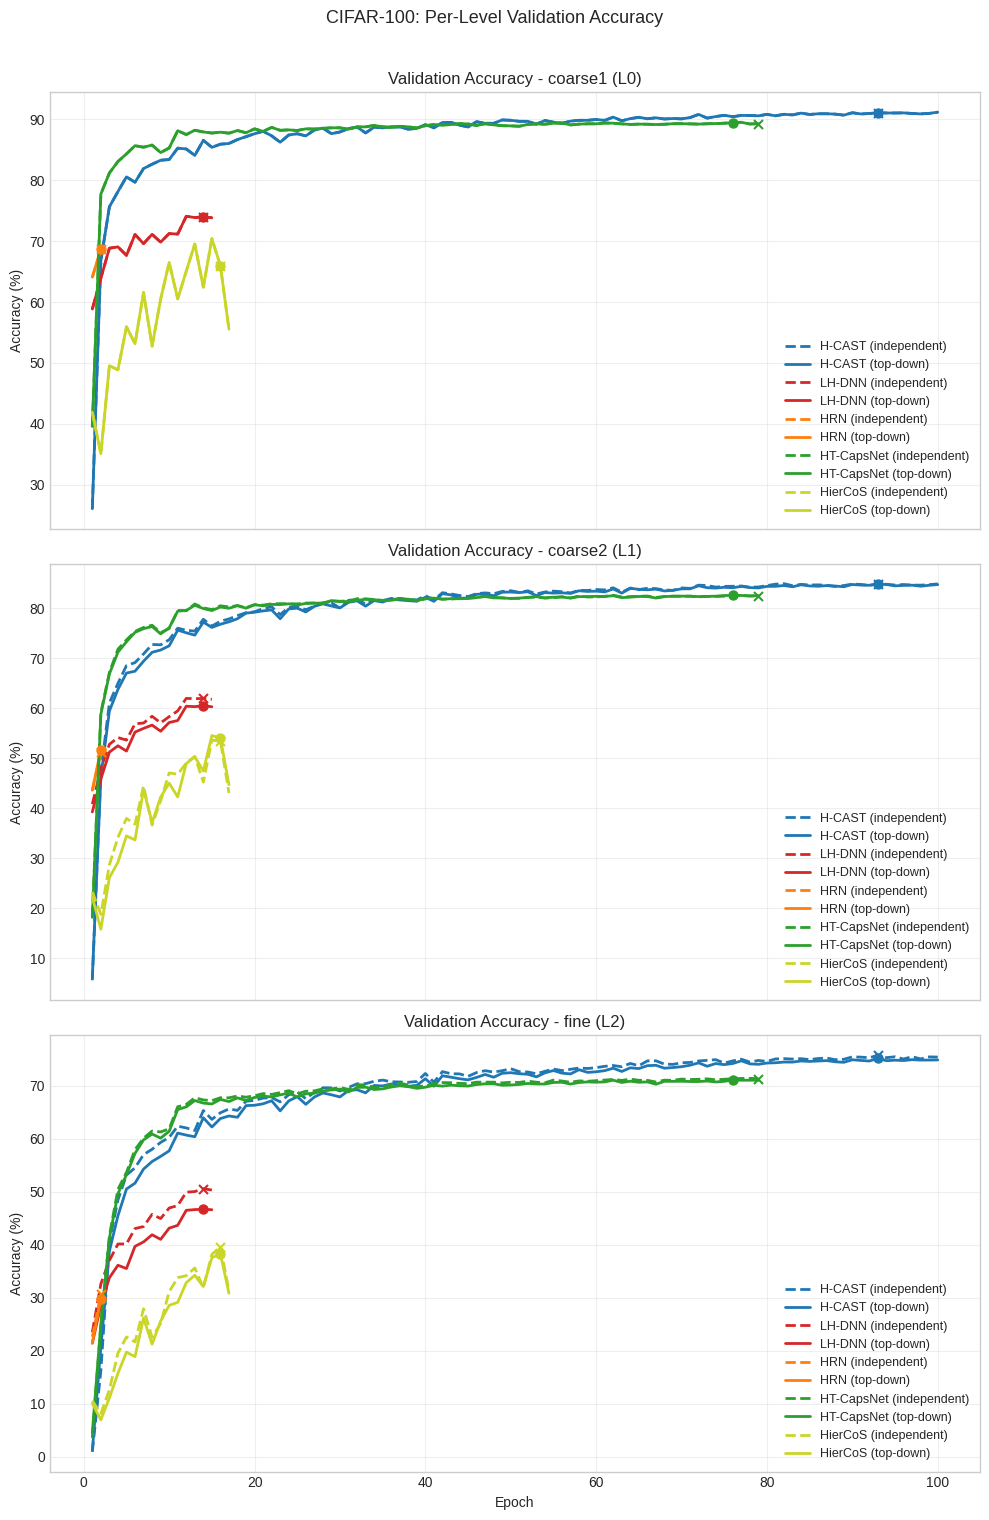

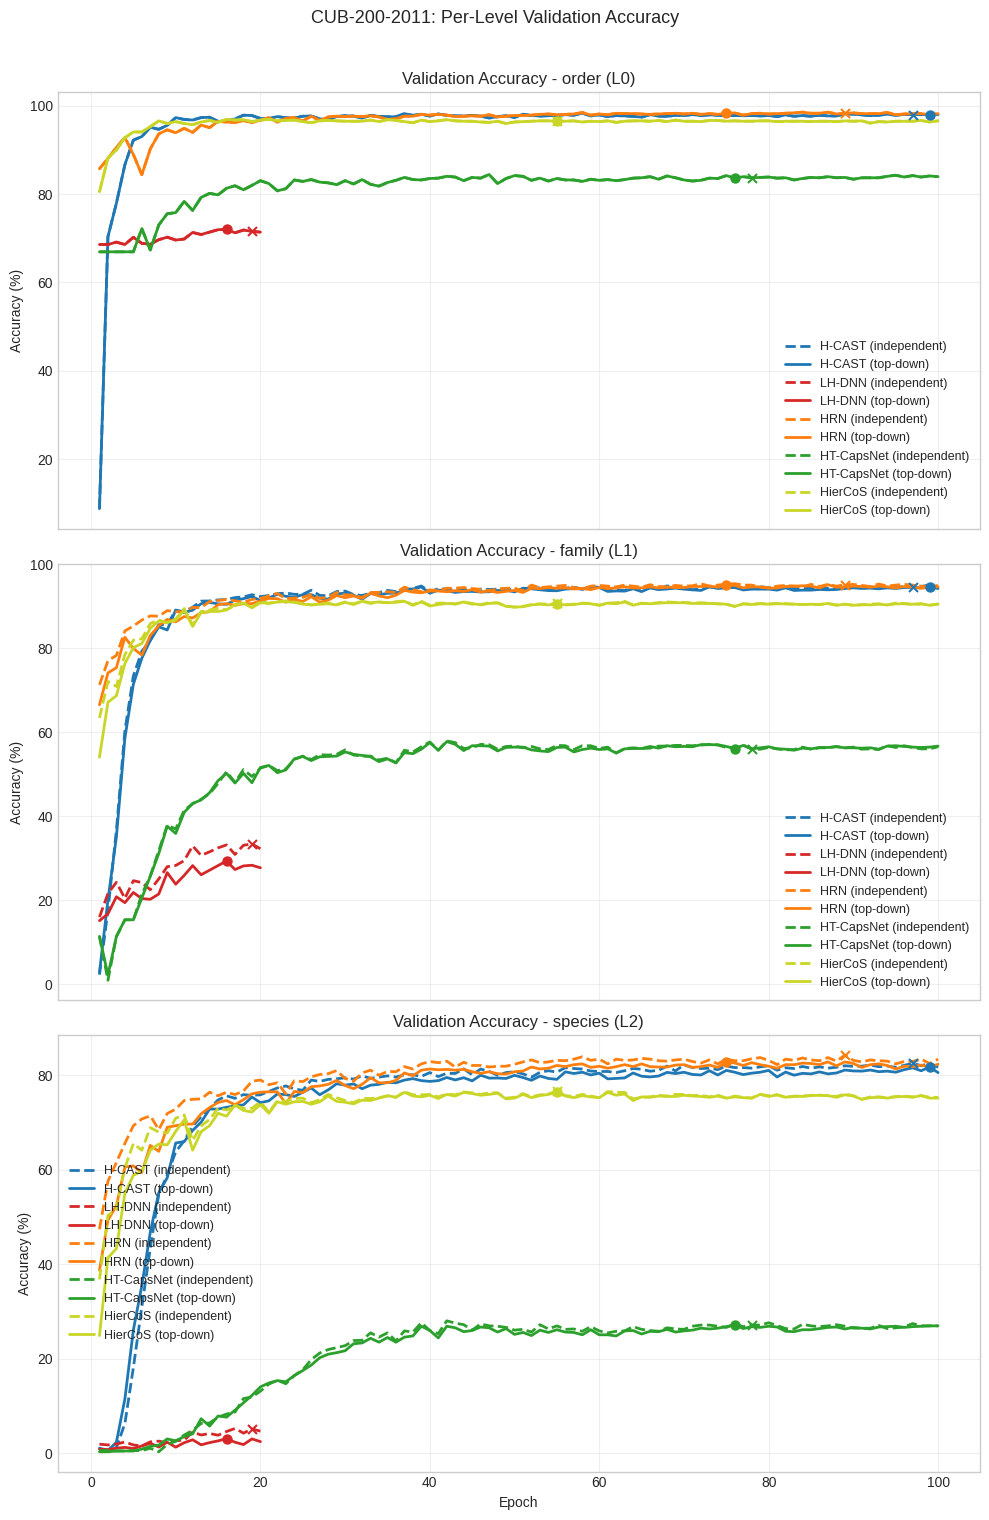

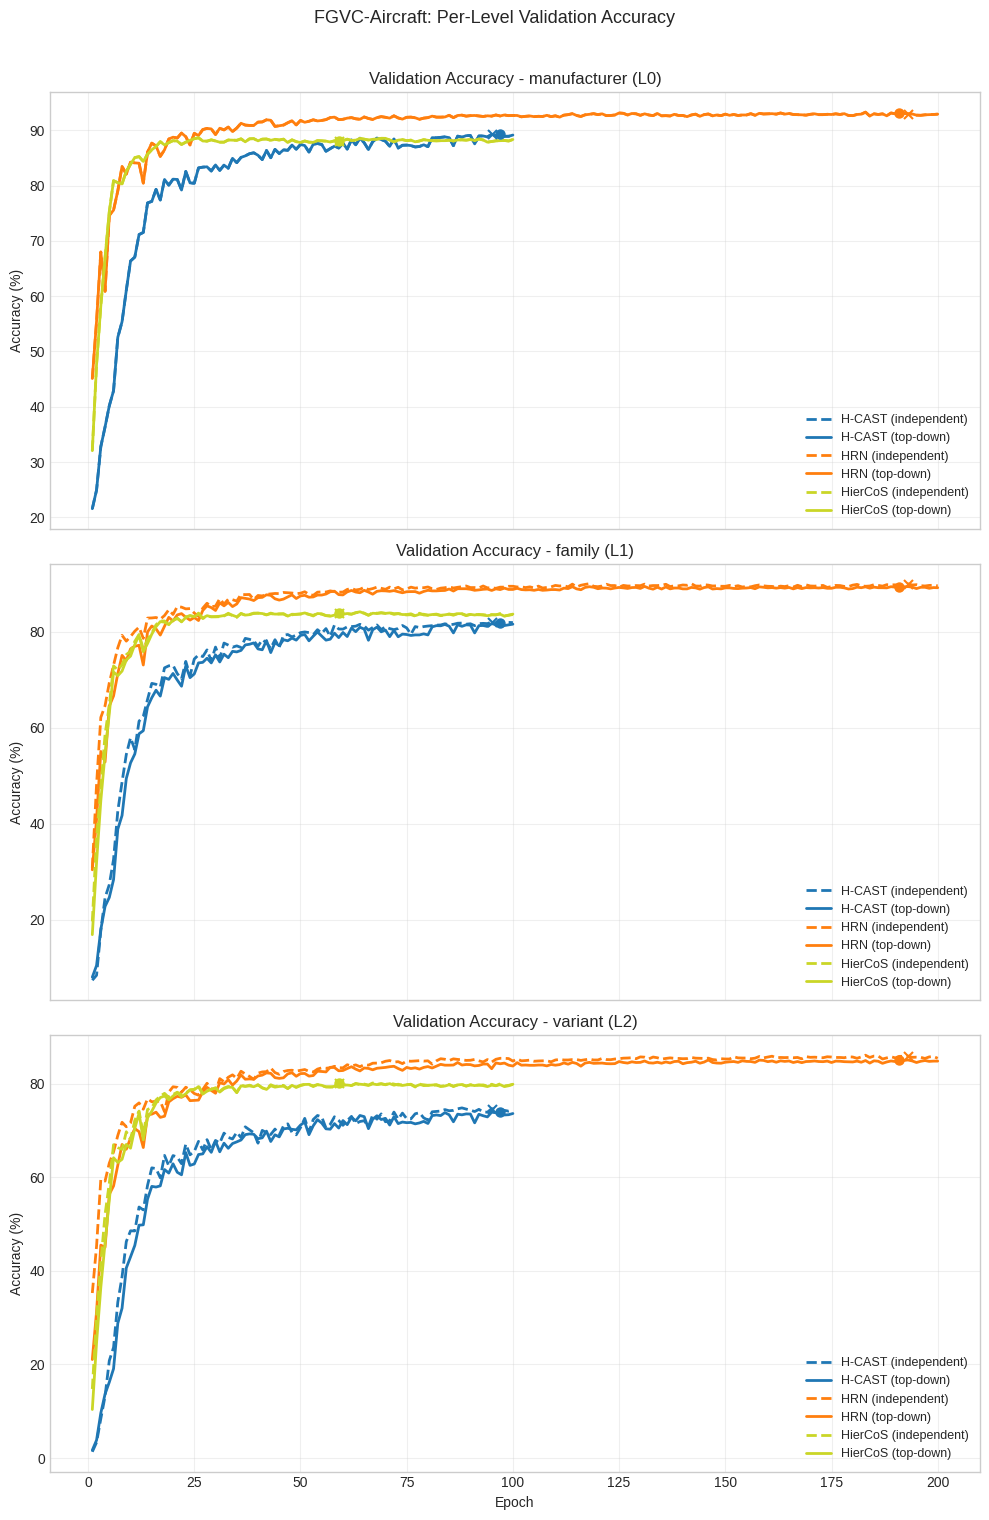

In [7]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Tables (Per Dataset)

The first model in each dataset section is used as baseline for deltas. When runs include mode-specific `test_results`, independent rows use the independent-best checkpoint and top-down rows use the top-down-best checkpoint.


In [8]:
analysis.show_final_test_tables()


### Dataset: `CIFAR-100`
Baseline run: **H-CAST**

| Metric | H-CAST | LH-DNN | HRN | HT-CapsNet | HierCoS |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 93/93 | 14/14 | 2/2 | 76/79 | 100/100 |
| FPA independent ↑ | <u>72.39%</u> | 43.83% (-28.56 pp) | n/a | n/a | **75.95% (+3.56 pp)** |
| FPA top-down ↑ | <u>74.28%</u> | 45.98% (-28.30 pp) | n/a | n/a | **76.20% (+1.92 pp)** |
| wAP independent ↑ | <u>77.63%</u> | 53.16% (-24.46 pp) | n/a | n/a | **78.65% (+1.02 pp)** |
| wAP top-down ↑ | <u>76.91%</u> | 49.84% (-27.06 pp) | n/a | n/a | **78.61% (+1.70 pp)** |
| TICE independent ↓ | <u>8.32%</u> | 18.38% (+10.06 pp) | n/a | n/a | **1.19% (-7.13 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | n/a | n/a | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>1.059</u> | 2.488 (+1.429) | n/a | n/a | **0.955 (-0.104)** |
| AHD top-down ↓ | <u>1.011</u> | 2.416 (+1.405) | n/a | n/a | **0.947 (-0.064)** |
| Acc independent coarse1 (L0) ↑ | <u>90.59%</u> | 73.51% (-17.08 pp) | n/a | n/a | **90.59% (+0.01 pp)** |
| Acc top-down coarse1 (L0) ↑ | <u>90.59%</u> | 73.51% (-17.08 pp) | n/a | n/a | **90.59% (+0.01 pp)** |
| Acc independent coarse2 (L1) ↑ | <u>84.59%</u> | 61.52% (-23.07 pp) | n/a | n/a | **85.85% (+1.26 pp)** |
| Acc top-down coarse2 (L1) ↑ | <u>84.58%</u> | 59.71% (-24.87 pp) | n/a | n/a | **85.84% (+1.26 pp)** |
| Acc independent fine (L2) ↑ | <u>75.20%</u> | 49.86% (-25.33 pp) | n/a | n/a | **76.25% (+1.06 pp)** |
| Acc top-down fine (L2) ↑ | <u>74.28%</u> | 45.98% (-28.30 pp) | n/a | n/a | **76.20% (+1.92 pp)** |

### Dataset: `CUB-200-2011`
Baseline run: **H-CAST**

| Metric | H-CAST | LH-DNN | HRN | HT-CapsNet | HierCoS |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 99/97 | 16/19 | 75/89 | 76/78 | 55/55 |
| FPA independent ↑ | <u>79.44%</u> | 1.66% (-77.78 pp) | **82.05% (+2.61 pp)** | 25.34% (-54.10 pp) | 76.08% (-3.36 pp) |
| FPA top-down ↑ | <u>80.96%</u> | 3.36% (-77.60 pp) | **83.24% (+2.29 pp)** | 26.30% (-54.65 pp) | 76.22% (-4.74 pp) |
| wAP independent ↑ | <u>84.21%</u> | 13.23% (-70.98 pp) | **86.55% (+2.34 pp)** | 34.24% (-49.97 pp) | 79.52% (-4.68 pp) |
| wAP top-down ↑ | <u>83.73%</u> | 11.04% (-72.70 pp) | **85.64% (+1.91 pp)** | 33.89% (-49.85 pp) | 79.46% (-4.27 pp) |
| TICE independent ↓ | 5.85% | 76.27% (+70.42 pp) | <u>5.36% (-0.49 pp)</u> | 11.80% (+5.94 pp) | **0.69% (-5.16 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.582</u> | 3.967 (+3.385) | **0.524 (-0.058)** | 2.689 (+2.106) | 0.732 (+0.150) |
| AHD top-down ↓ | <u>0.550</u> | 3.891 (+3.341) | **0.491 (-0.060)** | 2.660 (+2.109) | 0.727 (+0.177) |
| Acc independent order (L0) ↑ | <u>98.13%</u> | 71.23% (-26.90 pp) | **98.31% (+0.18 pp)** | 84.10% (-14.03 pp) | 96.81% (-1.33 pp) |
| Acc top-down order (L0) ↑ | <u>98.08%</u> | 71.23% (-26.85 pp) | **98.31% (+0.23 pp)** | 84.10% (-13.98 pp) | 96.81% (-1.28 pp) |
| Acc independent family (L1) ↑ | <u>93.61%</u> | 34.48% (-59.12 pp) | **93.76% (+0.15 pp)** | 56.75% (-36.86 pp) | 90.56% (-3.05 pp) |
| Acc top-down family (L1) ↑ | <u>93.44%</u> | 30.85% (-62.59 pp) | **93.91% (+0.47 pp)** | 56.61% (-36.83 pp) | 90.62% (-2.81 pp) |
| Acc independent species (L2) ↑ | <u>81.51%</u> | 5.42% (-76.10 pp) | **84.41% (+2.90 pp)** | 26.72% (-54.80 pp) | 76.30% (-5.21 pp) |
| Acc top-down species (L2) ↑ | <u>80.96%</u> | 3.36% (-77.60 pp) | **83.24% (+2.29 pp)** | 26.30% (-54.65 pp) | 76.22% (-4.74 pp) |

### Dataset: `FGVC-Aircraft`
Baseline run: **H-CAST**

| Metric | H-CAST | HRN | HierCoS |
|---|---:|---:|---:|
| Best epoch (TD/Ind) | 97/95 | 191/193 | 59/59 |
| FPA independent ↑ | 69.24% | **84.54% (+15.30 pp)** | <u>80.20% (+10.96 pp)</u> |
| FPA top-down ↑ | 72.31% | **85.92% (+13.61 pp)** | <u>80.41% (+8.10 pp)</u> |
| wAP independent ↑ | 78.55% | **89.37% (+10.81 pp)** | <u>83.08% (+4.53 pp)</u> |
| wAP top-down ↑ | 77.23% | **88.78% (+11.55 pp)** | <u>83.14% (+5.92 pp)</u> |
| TICE independent ↓ | 13.68% | <u>6.80% (-6.88 pp)</u> | **1.35% (-12.33 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.289 | **0.646 (-0.644)** | <u>0.934 (-0.355)</u> |
| AHD top-down ↓ | 1.208 | **0.592 (-0.616)** | <u>0.923 (-0.285)</u> |
| Acc independent manufacturer (L0) ↑ | 87.35% | **93.57% (+6.22 pp)** | <u>88.82% (+1.47 pp)</u> |
| Acc top-down manufacturer (L0) ↑ | 87.38% | **93.72% (+6.34 pp)** | <u>88.82% (+1.44 pp)</u> |
| Acc independent family (L1) ↑ | 81.38% | **91.20% (+9.82 pp)** | <u>84.44% (+3.05 pp)</u> |
| Acc top-down family (L1) ↑ | 79.90% | **90.75% (+10.85 pp)** | <u>84.62% (+4.72 pp)</u> |
| Acc independent variant (L2) ↑ | 73.93% | **86.82% (+12.89 pp)** | <u>80.41% (+6.47 pp)</u> |
| Acc top-down variant (L2) ↑ | 72.31% | **85.92% (+13.61 pp)** | <u>80.41% (+8.10 pp)</u> |